In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pink = "#FF69B4"
purple = "#C77DFF"
light_purple = "#D8B4FE"

In [42]:
df = pd.read_csv("hr.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [43]:
df.shape

(1470, 35)

In [44]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [45]:
df.info()

# Displays the data types and non-null values of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [46]:
df.isnull().sum()
# Checks whether the dataset contains any missing values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

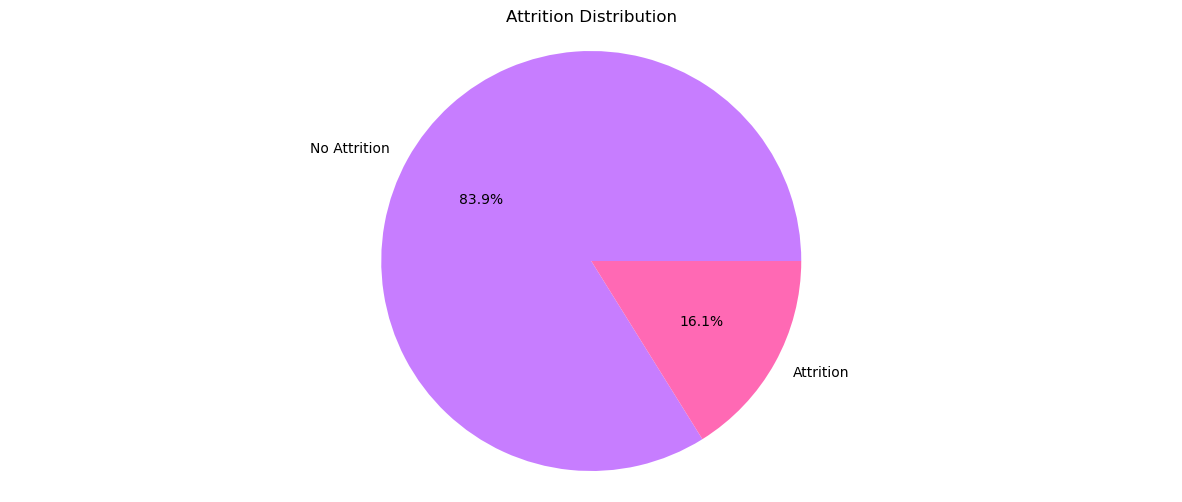

In [49]:
s = df["Attrition"].value_counts().values
s
plt.figure(figsize=(15,6))

plt.pie(
    s,
    labels=["No Attrition", "Attrition"],
    autopct="%1.1f%%",
    colors=[purple, pink]
)

plt.title("Attrition Distribution")
plt.axis("equal")
plt.show()
# Observation: Most employees stayed with the company, while a smaller
# proportion of employees left.

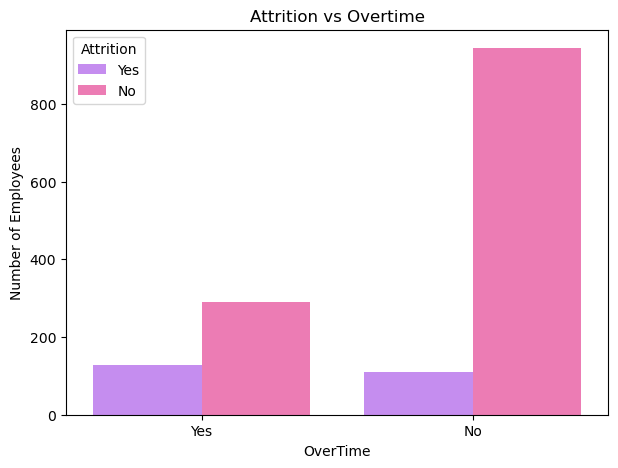

In [50]:
plt.figure(figsize=(7, 5))


sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df,
    palette=[purple, pink]
)
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.title("Attrition vs Overtime")

plt.show()

#Observation: Employees who work overtime show a higher proportion of attrition
#compared with employees who do not work overtime. 
#attrition MAY BE ASSOCIATED with overtime

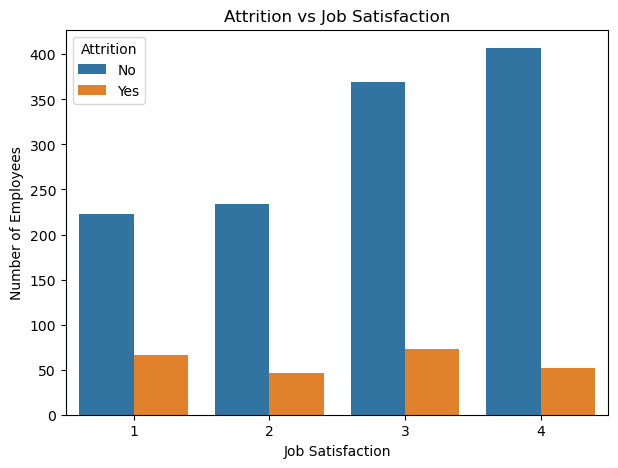

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.title("Attrition vs Job Satisfaction")

plt.show()

#Attrition occurs across all job satisfaction levels, but the 
#number of employees who stay is considerably higher than those who leave in each category.
#job satisfaction alone does not completely determine attrition.

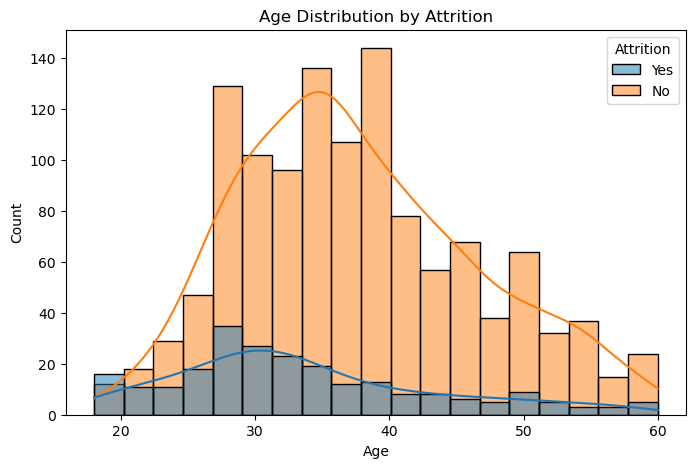

In [52]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", hue="Attrition", kde=True)

plt.title("Age Distribution by Attrition")

plt.show()

#Observation: Employees who experienced attrition tend to be younger
#than employees who stayed.

In [53]:
#Feature Engineering
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
#convert yes and no to 1 and 0
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [54]:
df = df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1)

df.head() 
# Removes columns that do not provide useful information for predicting attrition

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [55]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# X contains the input features
# y contains the target variable (Attrition)

In [56]:
X.select_dtypes(include="object").columns

# Identifies categorical columns containing text values

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

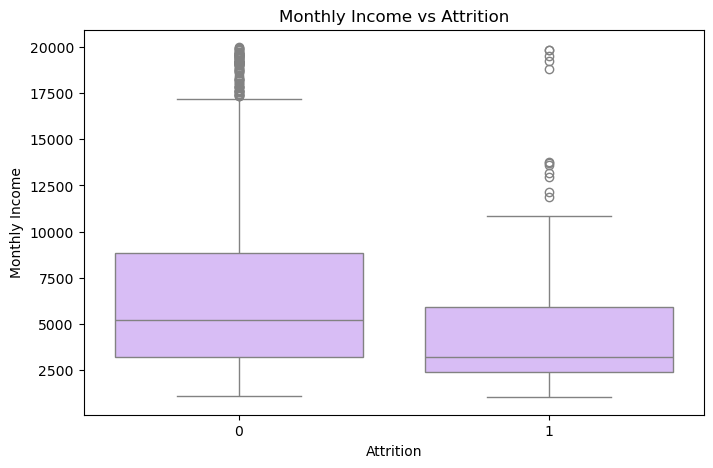

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, color=light_purple)
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.title("Monthly Income vs Attrition")

plt.show()

## Observation: Employees who left the company generally had lower
# monthly incomes than employees who stayed. The attrition group
# also contains some high-income outliers.

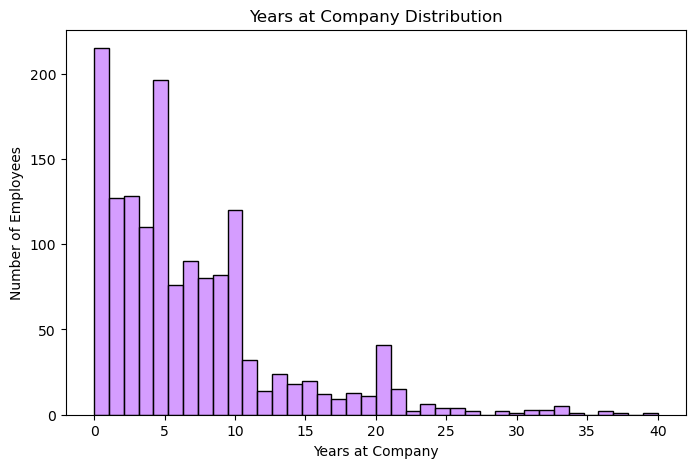

In [58]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="YearsAtCompany", color=purple)
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.title("Years at Company Distribution")

plt.show()
#Observation: Most employees have relatively fewer years at the company,
#while fewer employees have very long tenures.

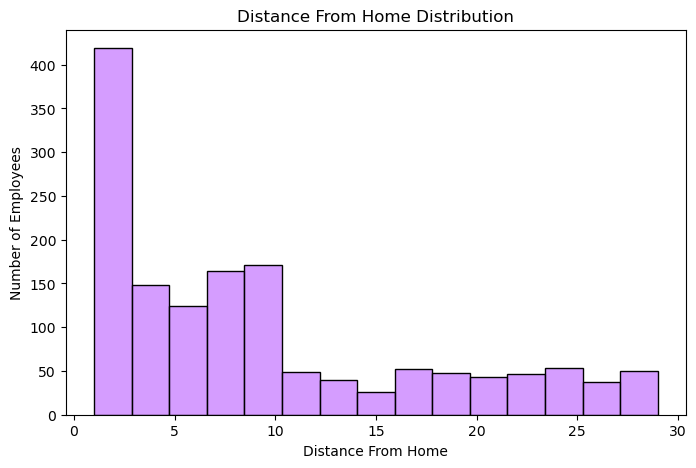

In [59]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="DistanceFromHome",
    bins=15,
    color=purple
)

plt.xlabel("Distance From Home")
plt.ylabel("Number of Employees")
plt.title("Distance From Home Distribution")

plt.show()
#Observation: Most employees live relatively close to the workplace,
#while fewer employees have longer distances from home.

In [60]:
X = pd.get_dummies(X, drop_first=True)

X.head()

# Converts categorical variables into numerical 0 and 1 columns
# so that they can be used by the machine learning model.

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)

# Checks the dimensions of the input features and target variable

X shape: (1470, 44)
y shape: (1470,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Splits the dataset into 80% training data and 20% testing data
# so that the model can be evaluated on unseen data.

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)

log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
# Use the trained model to predict Attrition
# for employees in the test dataset

y_pred = log.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

#around 86.05% of the test predictions were correct.

Accuracy: 0.8605442176870748


In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[237  10]
 [ 31  16]]


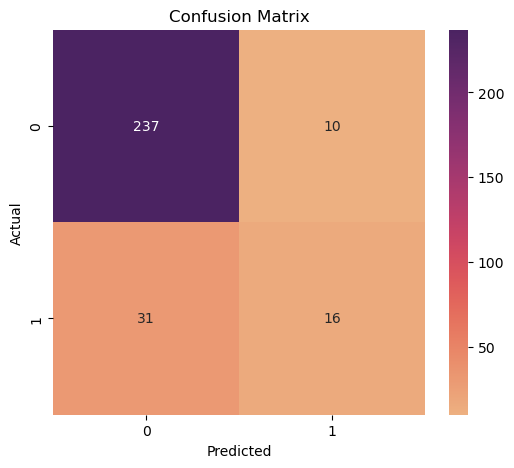

In [68]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="flare"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# Observation:
# The model correctly classified 237 employees who stayed and
# 16 employees who left. However, it incorrectly predicted
# 31 employees who actually left as staying.

In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



# Observation:
# The model performs better at identifying employees who stayed
# than employees who left. The recall for Attrition = 1 is 0.34,
# meaning the model correctly identifies 34% of employees who actually left.

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [70]:
import joblib

# Save the trained Logistic Regression model
# so that we can use it later in our Streamlit app.

joblib.dump(log, "attrition_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [71]:
#save scaler used during model training

joblib.dump(scaler, "attrition_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [72]:
# Save the exact feature names and their order
# that were used to train the model.

feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [74]:
#new model

features = [
    "Age",
    "BusinessTravel",
    "DistanceFromHome",
    "JobInvolvement",
    "JobLevel",
    "JobRole",
    "JobSatisfaction",
    "MaritalStatus",
    "MonthlyIncome",
    "OverTime",
    "TotalWorkingYears",
    "YearsAtCompany"
]

X_new = df[features].copy()
y_new = df["Attrition"]

X_new.head()

,Age,BusinessTravel,DistanceFromHome,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,TotalWorkingYears,YearsAtCompany
0,41,Travel_Rarely,1,3,2,Sales Executive,4,Single,5993,Yes,8,6
1,49,Travel_Frequently,8,2,2,Research Scientist,2,Married,5130,No,10,10
2,37,Travel_Rarely,2,2,1,Laboratory Technician,3,Single,2090,Yes,7,0
3,33,Travel_Frequently,3,3,1,Research Scientist,3,Married,2909,Yes,8,8
4,27,Travel_Rarely,2,3,1,Laboratory Technician,2,Married,3468,No,6,2


In [75]:
# Separate numerical and categorical features.
# Numerical features will be scaled later.
# Categorical features will be converted into dummy variables.

numerical_features = [
    "Age",
    "DistanceFromHome",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany"
]

categorical_features = [
    "BusinessTravel",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

In [76]:
# Convert categorical variables into numerical 0/1 columns
# so that Logistic Regression can use them.

X_new = pd.get_dummies(
    X_new,
    columns=categorical_features,
    drop_first=True
)

X_new.head()

,Age,DistanceFromHome,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,TotalWorkingYears,YearsAtCompany,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,3,2,4,5993,8,6,False,True,...,False,False,False,False,False,True,False,False,True,True
1,49,8,2,2,2,5130,10,10,True,False,...,False,False,False,False,True,False,False,True,False,False
2,37,2,2,1,3,2090,7,0,False,True,...,True,False,False,False,False,False,False,False,True,True
3,33,3,3,1,3,2909,8,8,True,False,...,False,False,False,False,True,False,False,True,False,True
4,27,2,3,1,2,3468,6,2,False,True,...,True,False,False,False,False,False,False,True,False,False


In [77]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
# 80% is used for training and 20% is kept for testing.

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

print("Training data:", X_train_new.shape)
print("Testing data:", X_test_new.shape)

Training data: (1176, 21)
Testing data: (294, 21)


In [78]:
from sklearn.preprocessing import StandardScaler

# StandardScaler puts numerical features on a similar scale.
# This helps Logistic Regression train more effectively.

scaler_new = StandardScaler()

X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [79]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model.
log_new = LogisticRegression(max_iter=1000)

# Train the model using the training data.
log_new.fit(X_train_new, y_train_new)

print("New Logistic Regression model trained successfully!")

New Logistic Regression model trained successfully!


In [80]:
# Use the trained model to predict Attrition
# for employees in the test dataset.

y_pred_new = log_new.predict(X_test_new)

print(y_pred_new)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [81]:
from sklearn.metrics import accuracy_score

accuracy_new = accuracy_score(y_test_new, y_pred_new)

print("Accuracy:", accuracy_new)

Accuracy: 0.8571428571428571


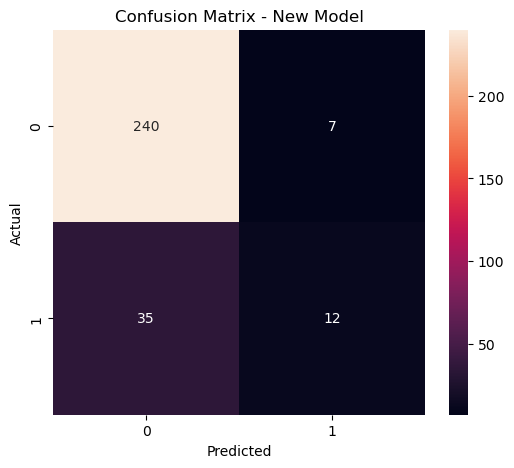

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create the confusion matrix
cm_new = confusion_matrix(y_test_new, y_pred_new)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_new,
    annot=True,
    fmt="d",
    cmap="rocket"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - New Model")

plt.show()

In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test_new, y_pred_new))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.63      0.26      0.36        47

    accuracy                           0.86       294
   macro avg       0.75      0.61      0.64       294
weighted avg       0.83      0.86      0.83       294



In [84]:
import joblib

# Save the new Logistic Regression model
# This model was trained using our selected 12 features.
joblib.dump(log_new, "attrition_model_new.pkl")

print("New model saved successfully!")

New model saved successfully!


In [85]:
# Save the scaler used to scale the new model's training data.
# The Streamlit app will use this same scaler for new employee inputs.

joblib.dump(scaler_new, "attrition_scaler_new.pkl")

print("New scaler saved successfully!")

New scaler saved successfully!


In [86]:
# Save the exact feature columns created after one-hot encoding.
# The Streamlit app will recreate its input data using these same columns.

feature_columns_new = X_new.columns.tolist()

joblib.dump(feature_columns_new, "feature_columns_new.pkl")

print("New feature columns saved successfully!")

New feature columns saved successfully!


In [87]:
# Find an employee from the test data that the model predicts as Attrition = 1

test_predictions = log_new.predict(X_test_new)

# Find positions where prediction is 1
leave_indices = np.where(test_predictions == 1)[0]

print("Number of employees predicted to leave:", len(leave_indices))

# Show the first predicted-leave employee
if len(leave_indices) > 0:
    index = leave_indices[0]
    print("Test sample position:", index)

Number of employees predicted to leave: 19
Test sample position: 25
